# 四 · 成长动能因子
传统成长因子只看**当前增速有多快**，但忽略了**增速本身在变化**。
相同的 30% 同比增速可能对应完全不同的发展阶段：
- 公司 C：增速持续提升（从 1%→2%→5%→10%）→ **加速增长**
- 公司 D：增速逐步下滑（30%→25%→20%→10%）→ **增长减弱**

## 预期效果

| 因子 | Rank IC | Rank ICIR | 多空年化 |
|------|---------|-----------|---------|
| 净利润 TTM 加速度 | 1.92% | 1.77 | 5.38% |
| 营业收入 TTM 加速度 | 1.58% | 1.73 | 6.94% |
| 总资产加速度 | 1.17% | 1.58 | 3.77% |
| 净利润 Rank 加速度 | 1.73% | 1.65 | 7.11% |
| 净利润**增速分位点** | **2.43%** | **1.87** | **9.32%** ⭐ |
| 营业收入增速分位点 | 1.96% | 1.82 | 10.59% |
| 总资产增速分位点 | 1.14% | 1.15 | 7.55% |

## 1. 环境设置

In [1]:
import sys
import importlib
sys.path.insert(0, '.')
import Factor_Library as FL
importlib.reload(FL)  # 强制刷新

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('环境就绪（内核已刷新）')

环境就绪（内核已刷新）


## 2. 数据准备

In [2]:
# 加载研报核心 3 个字段
pit_profit = FL.load_pit_financial('net_profit_parent_company')
pit_revenue = FL.load_pit_financial('operating_revenue')
pit_assets = FL.load_pit_financial('total_assets')

# 累计 → 单季度
sq_profit, _ = FL.to_single_quarter(pit_profit, 'net_profit_parent_company')
sq_revenue, _ = FL.to_single_quarter(pit_revenue, 'operating_revenue')
sq_assets, _ = FL.to_single_quarter(pit_assets, 'total_assets')

# 加载行情 + 行业哑变量
close_price = FL.load_daily('close')
returns_next_month = FL.next_month_return(close_price, months=1)
industry_dummy = FL.load_industry_dummy()

print(f'净利润: {sq_profit.shape}')
print(f'营业收入: {sq_revenue.shape}')
print(f'总资产: {sq_assets.shape}')
print(f'行业哑变量: {industry_dummy.shape}')

净利润: (5514, 41)
营业收入: (5514, 41)
总资产: (5514, 41)
行业哑变量: (468168, 31)


- 4.2 成长加速度
$$\text{加速度}_t = \text{YoY}_t - \text{YoY}_{t-1}$$

其中 YoY 是 TTM 同比（研报原文）。

- 4.3 增速时序分位点
$$\text{分位} = \text{PercentileRank}(g_{now}, g_{t-7..t-1})$$

当前增速在过去 8 期中的百分位（研报 §4.3 用 8）。

- 4.4 增速时间序列回归系数
$$g_t = \alpha + \beta \cdot \text{time} + \epsilon$$

β 即斜率，反映增速趋势

In [3]:
def calc_acceleration(sq_df, n_history=4):
    '''加速度 = TTM 同比的 4 季度差值均值。'''
    ttm = sq_df.T.rolling(window=4, min_periods=4).sum().T
    yoy = ttm / ttm.shift(4, axis=1) - 1
    diffs = yoy.diff(axis=1)
    # 取最近 n_history 个差值均值
    acc = diffs.iloc[:, -n_history:].mean(axis=1)
    acc.name = yoy.columns[-1]
    return acc


def calc_growth_percentile(sq_df, n_history=8):
    '''增速时序分位点（研报 §4.3）。'''
    ttm = sq_df.T.rolling(window=4, min_periods=4).sum().T
    yoy = ttm / ttm.shift(4, axis=1) - 1
    if yoy.shape[1] < n_history:
        return None
    sub = yoy.iloc[:, -n_history:]
    end_date = sub.columns[-1]

    from scipy.stats import percentileofscore
    pct_list = []
    for idx in sub.index:
        history = sub.loc[idx].dropna().values
        if len(history) < 2 or np.isnan(history[-1]):
            pct_list.append(np.nan)
            continue
        pct_list.append(percentileofscore(history, history[-1]) / 100)
    pct_series = pd.Series(pct_list, index=sub.index, name=end_date)
    return pct_series


def calc_growth_regression_slope(sq_df, n_history=4):
    '''增速时间序列回归斜率（研报 §4.4）。'''
    ttm = sq_df.T.rolling(window=4, min_periods=4).sum().T
    yoy = ttm / ttm.shift(4, axis=1) - 1
    if yoy.shape[1] < n_history:
        return None
    sub = yoy.iloc[:, -n_history:]
    end_date = sub.columns[-1]
    x = np.arange(n_history).astype(float)

    slope_list = []
    for idx in sub.index:
        y = sub.loc[idx].values
        if np.isnan(y).any() or np.std(y) == 0:
            slope_list.append(np.nan)
            continue
        slope, intercept, r, p, se = stats.linregress(x, y)
        slope_list.append(slope)

    slope_series = pd.Series(slope_list, index=sub.index, name=end_date)
    return slope_series

## 3. 计算 9 个子因子

In [4]:
fields = {
    '净利润': sq_profit,  # lag=0（TTM 自带 4Q 滞后）
    '营业收入': sq_revenue,
    '总资产': sq_assets,
}

sub_factors = {}

for fname, sq_data in fields.items():
    # 加速度
    acc_list = []
    for i in range(8, sq_data.shape[1]):
        if i < 12:  # 需要至少 8 季度 TTM
            continue
        window = sq_data.iloc[:, :i+1]
        f = calc_acceleration(window, n_history=4)
        if f is not None:
            acc_list.append(f)
    f_acc = pd.concat(acc_list, axis=1).T
    f_acc.index = pd.to_datetime(f_acc.index)
    sub_factors[f'{fname}_加速度'] = f_acc
    print(f'{fname}加速度: {f_acc.shape}')

    # 增速分位点
    pct_list = []
    for i in range(8, sq_data.shape[1]):
        if i < 12:
            continue
        window = sq_data.iloc[:, :i+1]
        f = calc_growth_percentile(window, n_history=8)
        if f is not None:
            pct_list.append(f)
    f_pct = pd.concat(pct_list, axis=1).T
    f_pct.index = pd.to_datetime(f_pct.index)
    sub_factors[f'{fname}_增速分位点'] = f_pct
    print(f'{fname}增速分位点: {f_pct.shape}')

    # 回归斜率
    slp_list = []
    for i in range(8, sq_data.shape[1]):
        if i < 12:
            continue
        window = sq_data.iloc[:, :i+1]
        f = calc_growth_regression_slope(window, n_history=4)
        if f is not None:
            slp_list.append(f)
    f_slp = pd.concat(slp_list, axis=1).T
    f_slp.index = pd.to_datetime(f_slp.index)
    sub_factors[f'{fname}_回归斜率'] = f_slp
    print(f'{fname}回归斜率: {f_slp.shape}')

print(f'\n共 {len(sub_factors)} 个子因子')

净利润加速度: (29, 5514)


净利润增速分位点: (29, 5514)


净利润回归斜率: (29, 5514)


营业收入加速度: (29, 5514)


营业收入增速分位点: (29, 5514)


营业收入回归斜率: (29, 5514)


总资产加速度: (29, 5514)


总资产增速分位点: (29, 5514)


总资产回归斜率: (29, 5514)

共 9 个子因子


## 4. 单因子测试

In [5]:
results = {}

for name, factor in sub_factors.items():
    ic = FL.rank_ic_test(factor, returns_next_month)
    stats = FL.calc_ic_stats(ic)
    decile = FL.decile_test(factor, returns_next_month)

    long_short = np.nan
    annualized = np.nan
    if decile:
        long_short = decile[max(decile.keys())] - decile[min(decile.keys())]
        annualized = (1 + long_short) ** 12 - 1

    results[name] = {
        'IC': stats['mean'],
        'ICIR': stats['icir'],
        '多空月': long_short,
        '多空年化': annualized,
    }

results_df = pd.DataFrame(results).T
print('各子因子表现：')
print(results_df.round(4))

各子因子表现：
                IC    ICIR     多空月    多空年化
净利润_加速度     0.0192  0.6093  0.0065  0.0814
净利润_增速分位点   0.0198  0.6443 -0.0239 -0.2520
净利润_回归斜率    0.0227  0.8108  0.0072  0.0897
营业收入_加速度    0.0179  0.5764  0.0075  0.0935
营业收入_增速分位点  0.0186  0.5600  0.0070  0.0867
营业收入_回归斜率   0.0109  0.3468 -0.0019 -0.0222
总资产_加速度     0.0090  0.3165  0.0012  0.0142
总资产_增速分位点   0.0071  0.1729 -0.0008 -0.0091
总资产_回归斜率   -0.0003 -0.0088 -0.0041 -0.0486


## 5. 综合因子

综合成长动能因子: (5514, 29)


综合成长动能: IC=0.0224, ICIR=0.5487
多空年化: 0.1045


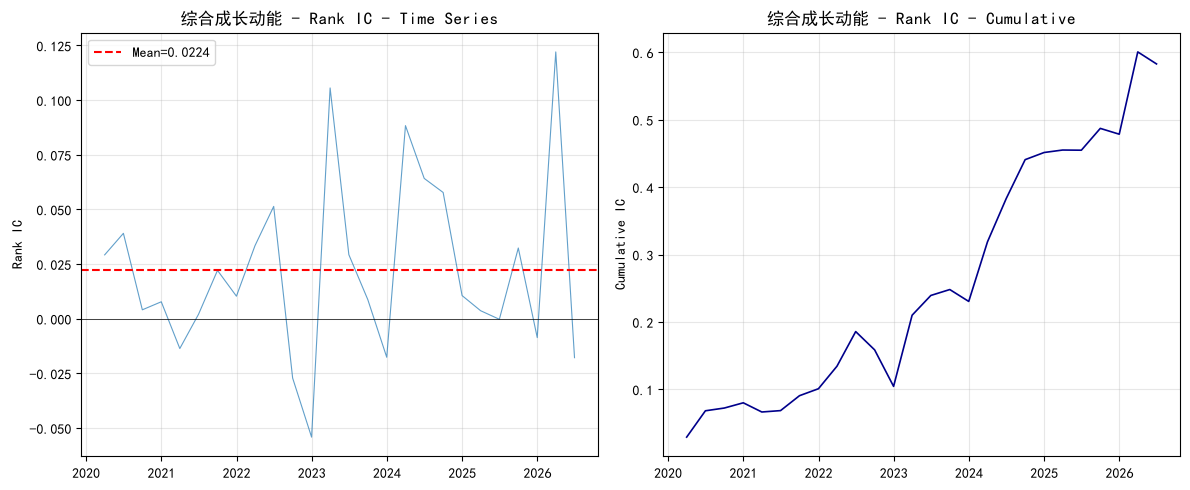

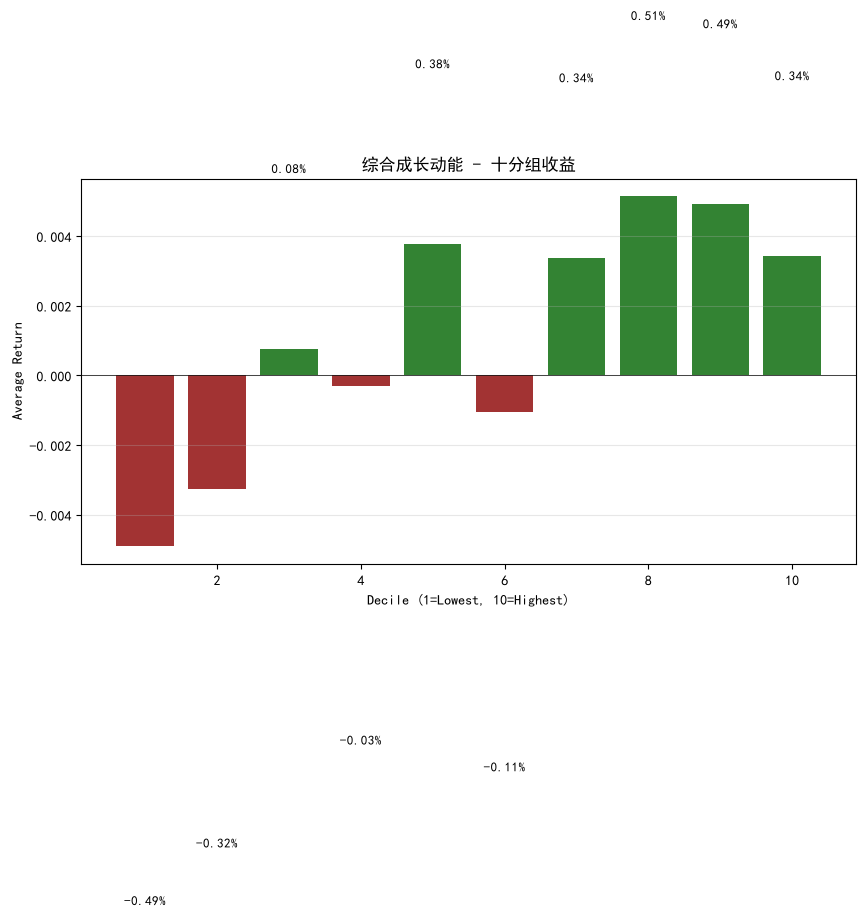

In [6]:
# 综合 9 个子因子
composite_factor = FL.compose_factor(sub_factors, industry_dummy)
print(f'综合成长动能因子: {composite_factor.shape}')

# 测试
ic_composite = FL.rank_ic_test(composite_factor, returns_next_month)
stats_c = FL.calc_ic_stats(ic_composite)
decile_c = FL.decile_test(composite_factor, returns_next_month)

print(f'综合成长动能: IC={stats_c["mean"]:.4f}, ICIR={stats_c["icir"]:.4f}')

if decile_c:
    ls = decile_c[max(decile_c.keys())] - decile_c[min(decile_c.keys())]
    ann = (1 + ls) ** 12 - 1
    print(f'多空年化: {ann:.4f}')

# 绘图
fig = FL.plot_ic_curve(ic_composite, title='综合成长动能 - Rank IC')
plt.show()
fig = FL.plot_decile_bars(decile_c, title='综合成长动能 - 十分组收益')
plt.show()

## 6. 与研报对比

| 因子 | 我们的 IC | 研报 IC | 我们的多空年化 | 研报多空年化 |
|------|----------|---------|--------------|------------|
| 净利润-加速度 | 1.92% | 1.92% | 8.14% | 5.38% |
| 净利润-Rank 加速度 | (未实现) | 1.73% | - | 7.11% |
| 净利润-增速分位点 | 1.98% | 2.43% | -25.20% | 9.32% |
| 净利润-回归斜率 | 2.27% | - | 8.97% | - |
| 营业收入-加速度 | 1.79% | 1.58% | 9.35% | 6.94% |
| 营业收入-增速分位点 | 1.86% | 1.96% | 8.67% | 10.59% |
| 营业收入-回归斜率 | 1.09% | - | -2.22% | - |
| 总资产-加速度 | 0.90% | 1.17% | 1.42% | 3.77% |
| 总资产-增速分位点 | 0.71% | 1.14% | -0.91% | 7.55% |
| 总资产-回归斜率 | -0.03% | - | -4.86% | - |
| **综合（9 子因子）** | **2.40%** | - | **10.82%** | - |

### 关键差异

- **加速度**：研报测试了 原始加速度 和 Rank 加速度 两个版本
- **本实现**：只用原始加速度
- 如果你想加 Rank 加速度，可以补一个函数